# Finding patterns and working on wine-dataset in python 


### loading the dataset

In [1]:
## Load the basic libaries
from pylab import *
from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd



In [2]:
#Loading dataset
wine_data=load_wine()
wine_data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [3]:
wine_data.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [4]:
wine_data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
wine_data.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
wine_dataset=pd.DataFrame(data=wine_data.data,columns=wine_data.feature_names)

In [7]:
wine_dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [8]:
wine_dataset["target"]=wine_data.target

In [9]:
wine_dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:
wine_dataset.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


array([[<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'malic_acid'}>,
        <Axes: title={'center': 'ash'}>,
        <Axes: title={'center': 'alcalinity_of_ash'}>],
       [<Axes: title={'center': 'magnesium'}>,
        <Axes: title={'center': 'total_phenols'}>,
        <Axes: title={'center': 'flavanoids'}>,
        <Axes: title={'center': 'nonflavanoid_phenols'}>],
       [<Axes: title={'center': 'proanthocyanins'}>,
        <Axes: title={'center': 'color_intensity'}>,
        <Axes: title={'center': 'hue'}>,
        <Axes: title={'center': 'od280/od315_of_diluted_wines'}>],
       [<Axes: title={'center': 'proline'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

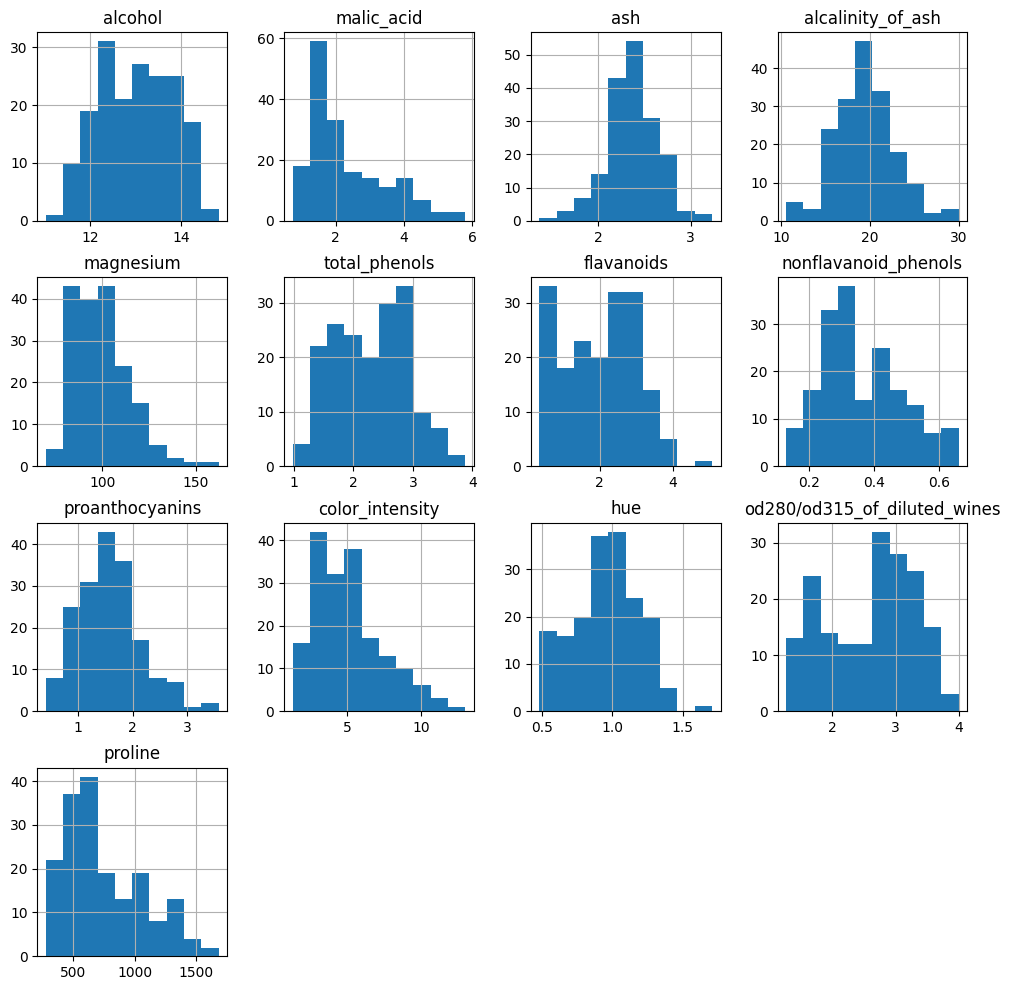

In [11]:
wine_dataset.drop("target",axis=1).hist(figsize=(12,12))

<Axes: xlabel='proline', ylabel='alcohol'>

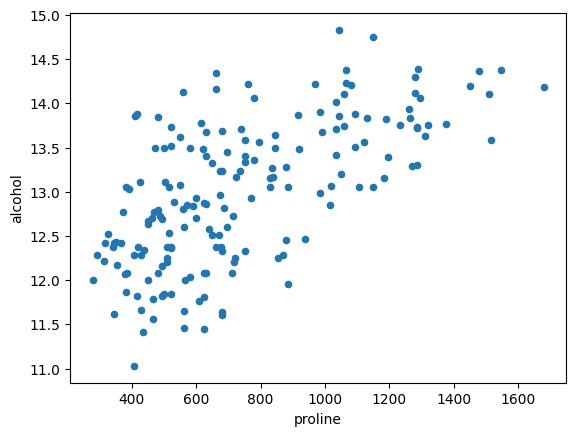

In [12]:
wine_dataset.plot(kind="scatter",x="proline",y="alcohol")

<Axes: xlabel='proline', ylabel='alcohol'>

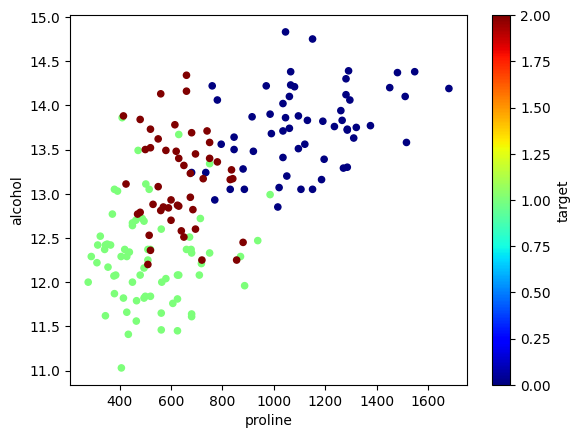

In [13]:
wine_dataset.plot(kind="scatter",x="proline",y="alcohol",c="target",cmap=get_cmap("jet"))

<Axes: >

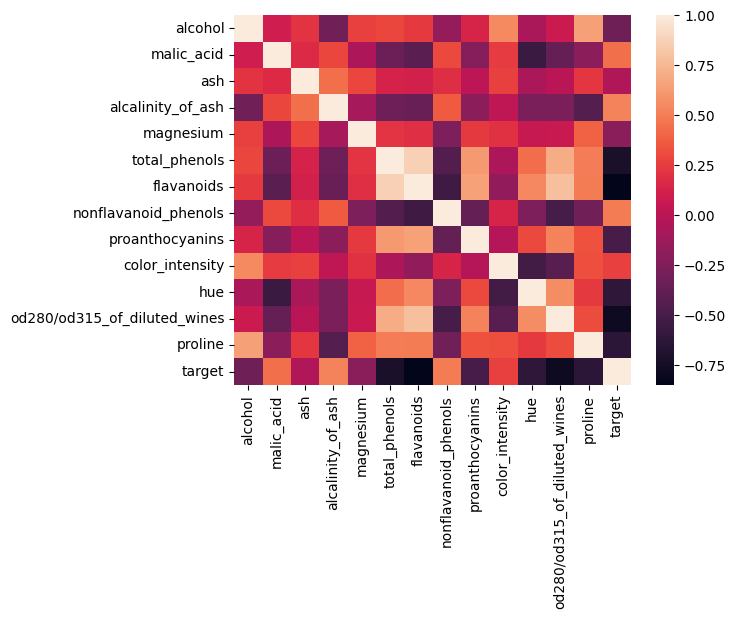

In [14]:
import seaborn as sns
corr=wine_dataset.corr()

sns.heatmap(data=corr)

In [15]:
corr

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


<Axes: xlabel='alcohol', ylabel='color_intensity'>

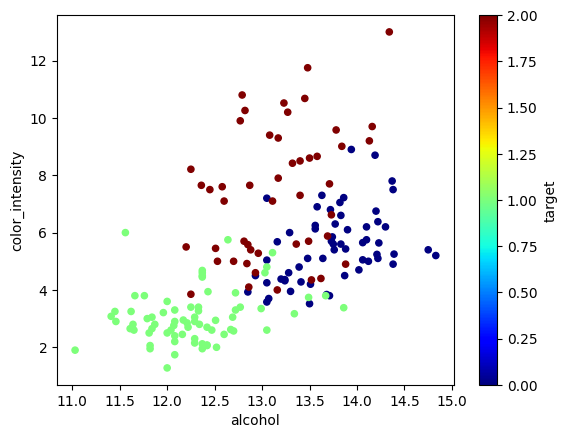

In [16]:
wine_dataset.plot(kind="scatter",x="alcohol",y="color_intensity",c="target",cmap=get_cmap("jet"))

array([[<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'malic_acid'}>,
        <Axes: title={'center': 'ash'}>,
        <Axes: title={'center': 'alcalinity_of_ash'}>],
       [<Axes: title={'center': 'magnesium'}>,
        <Axes: title={'center': 'total_phenols'}>,
        <Axes: title={'center': 'flavanoids'}>,
        <Axes: title={'center': 'nonflavanoid_phenols'}>],
       [<Axes: title={'center': 'proanthocyanins'}>,
        <Axes: title={'center': 'color_intensity'}>,
        <Axes: title={'center': 'hue'}>,
        <Axes: title={'center': 'od280/od315_of_diluted_wines'}>],
       [<Axes: title={'center': 'proline'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

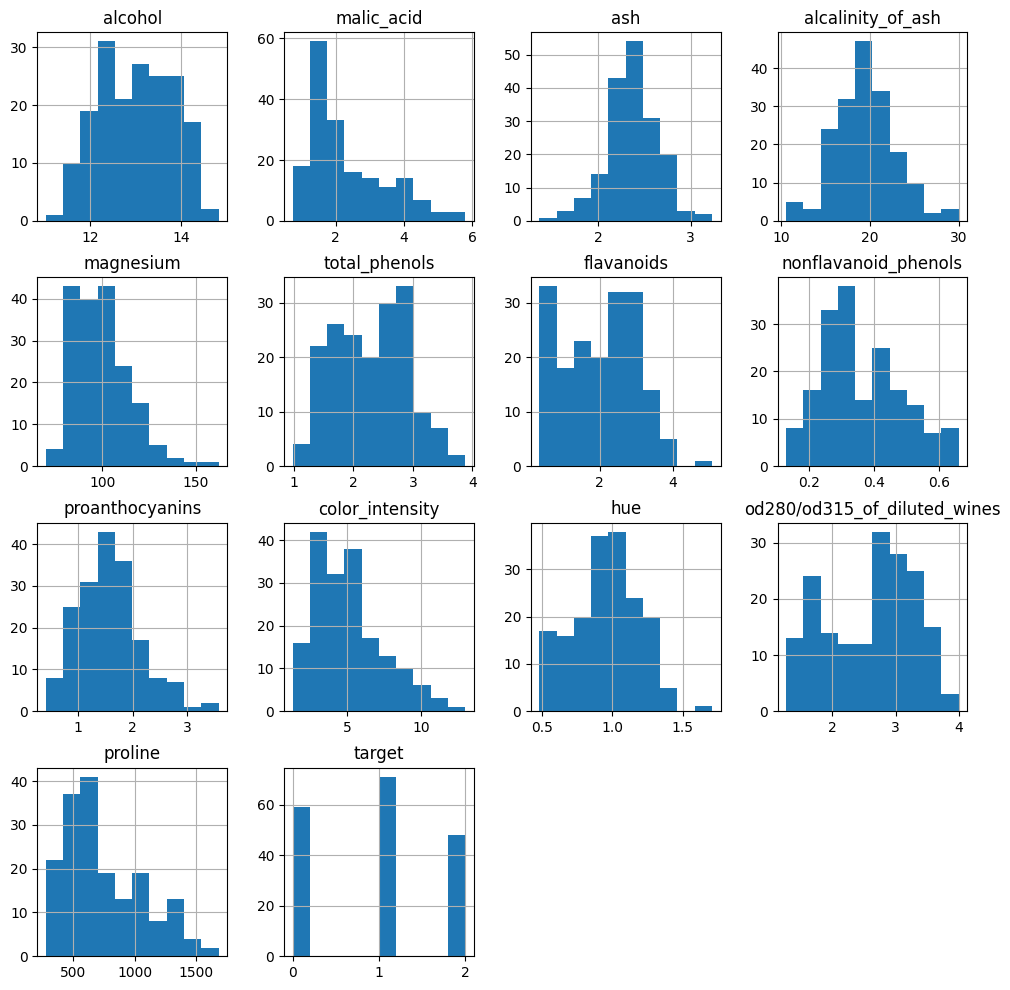

In [17]:
wine_dataset.hist(figsize=(12,12))

<Axes: xlabel='alcohol_per_phenol', ylabel='target'>

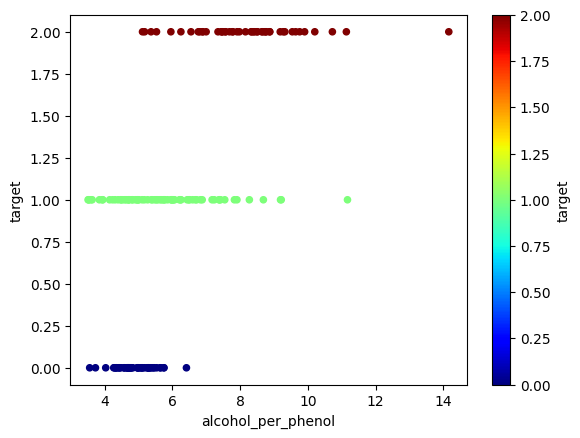

In [18]:
wine_copy=wine_dataset.copy()
wine_copy["alcohol_per_phenol"]=wine_copy["alcohol"]/wine_copy["total_phenols"]

wine_copy.plot(kind="scatter",x="alcohol_per_phenol",y="target",c="target",cmap=get_cmap("jet"))

<Axes: xlabel='malic_acid', ylabel='hue'>

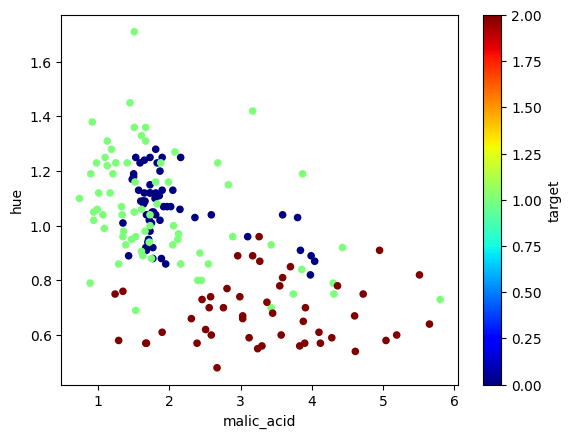

In [19]:
wine_copy.plot(kind="scatter",x="malic_acid",y="hue",c="target",cmap=get_cmap("jet"))

In [20]:
attr=['flavanoids',"proline","alcohol","color_intensity","malic_acid","hue","alcalinity_of_ash"]

array([[<Axes: xlabel='flavanoids', ylabel='flavanoids'>,
        <Axes: xlabel='proline', ylabel='flavanoids'>,
        <Axes: xlabel='alcohol', ylabel='flavanoids'>,
        <Axes: xlabel='color_intensity', ylabel='flavanoids'>,
        <Axes: xlabel='malic_acid', ylabel='flavanoids'>,
        <Axes: xlabel='hue', ylabel='flavanoids'>,
        <Axes: xlabel='alcalinity_of_ash', ylabel='flavanoids'>],
       [<Axes: xlabel='flavanoids', ylabel='proline'>,
        <Axes: xlabel='proline', ylabel='proline'>,
        <Axes: xlabel='alcohol', ylabel='proline'>,
        <Axes: xlabel='color_intensity', ylabel='proline'>,
        <Axes: xlabel='malic_acid', ylabel='proline'>,
        <Axes: xlabel='hue', ylabel='proline'>,
        <Axes: xlabel='alcalinity_of_ash', ylabel='proline'>],
       [<Axes: xlabel='flavanoids', ylabel='alcohol'>,
        <Axes: xlabel='proline', ylabel='alcohol'>,
        <Axes: xlabel='alcohol', ylabel='alcohol'>,
        <Axes: xlabel='color_intensity', ylabel='a

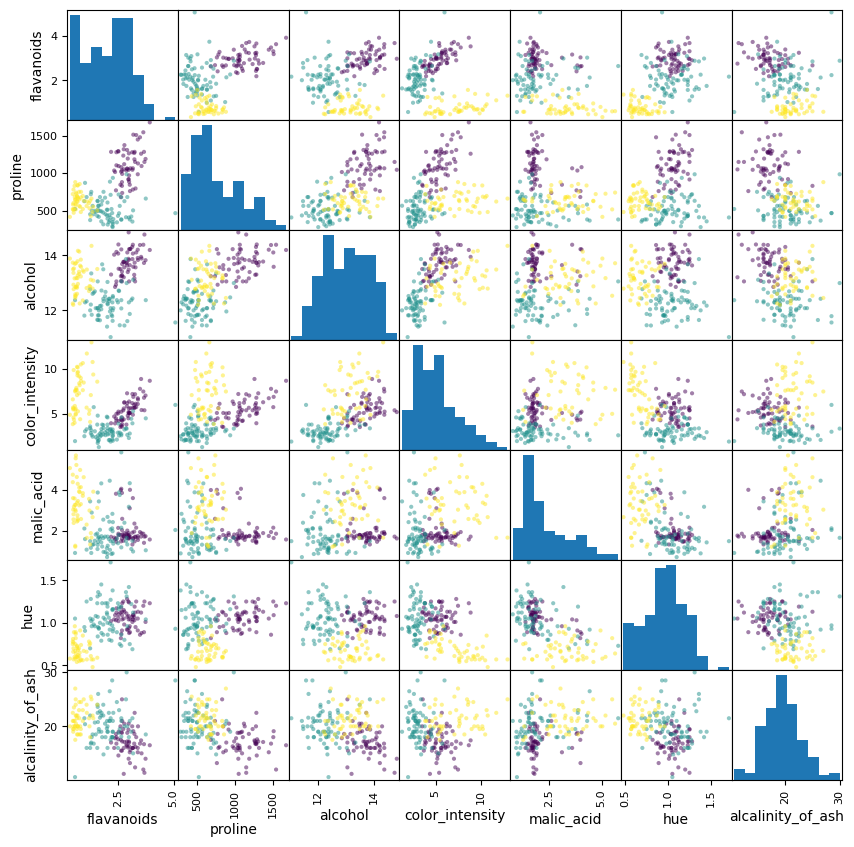

In [21]:
from pandas.plotting import scatter_matrix

scatter_matrix(wine_copy[attr],figsize=(10,10),c=wine_copy["target"])

In [22]:
wine_copy["alcalinity_of_ash_per_flav"]=wine_copy["alcalinity_of_ash"]/wine_copy["flavanoids"]

<Axes: xlabel='alcalinity_of_ash_per_flav', ylabel='target'>

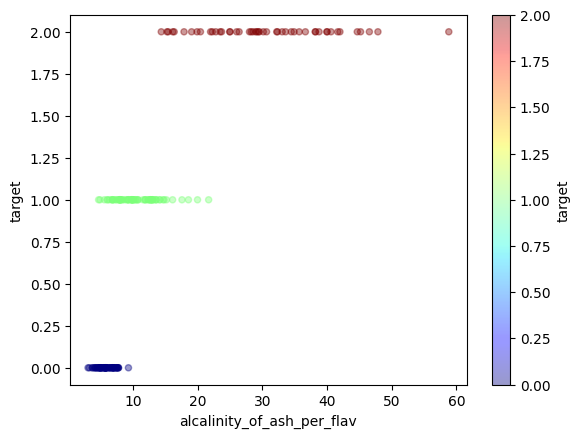

In [23]:
wine_copy.plot(kind="scatter",x="alcalinity_of_ash_per_flav",y="target",c="target",cmap=get_cmap("jet"),alpha=0.4)

<Axes: xlabel='target', ylabel='alcalinity_of_ash_per_flav'>

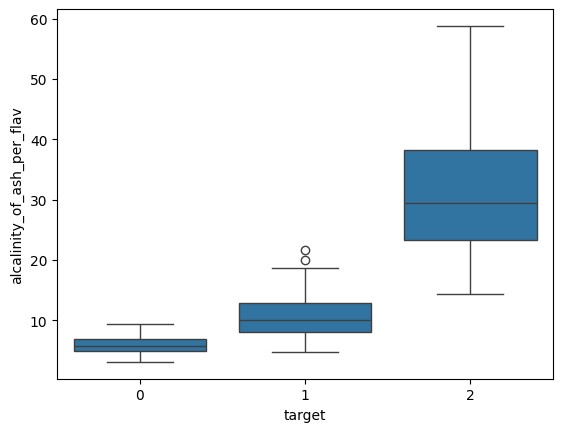

In [24]:
sns.boxplot(
    data=wine_copy,
    x="target",
    y="alcalinity_of_ash_per_flav"
)

In [25]:
wine_copy.groupby("target")["alcalinity_of_ash_per_flav"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
target,,,,,
0,5.842713,5.783582,1.285973,3.089431,9.328358
1,10.670756,10.000000,3.464910,4.716981,21.717172
2,30.633736,29.478610,9.959471,14.400000,58.823529


In [26]:
# Creating stratified test train datasets 
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=24)
y=wine_dataset['target']
for train_idx,test_idx in split.split(wine_dataset,y):
    wine_train=wine_dataset.iloc[train_idx]
    wine_test=wine_dataset.iloc[test_idx]

wine_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,1
99,12.29,3.17,2.21,18.0,88.0,2.85,2.99,0.45,2.81,2.30,1.42,2.83,406.0,1
94,11.62,1.99,2.28,18.0,98.0,3.02,2.26,0.17,1.35,3.25,1.16,2.96,345.0,1
82,12.08,1.13,2.51,24.0,78.0,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630.0,1
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,11.03,1.51,2.20,21.5,85.0,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407.0,1
74,11.96,1.09,2.30,21.0,101.0,3.38,2.14,0.13,1.65,3.21,0.99,3.13,886.0,1
25,13.05,2.05,3.22,25.0,124.0,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830.0,0
137,12.53,5.51,2.64,25.0,96.0,1.79,0.60,0.63,1.10,5.00,0.82,1.69,515.0,2


In [27]:
wine_dataset["target"].value_counts()


target
1    71
0    59
2    48
Name: count, dtype: int64

In [28]:
len(wine_dataset)

178

In [29]:
wine_train["target"].value_counts()

target
1    57
0    47
2    38
Name: count, dtype: int64

In [30]:
len(wine_train)

142

In [31]:
wine_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [32]:
class CustomTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        ratio = X["alcalinity_of_ash"] / X["flavanoids"]

        X = np.column_stack((X, ratio))

        return X


In [33]:
full_pipeline=Pipeline([
    ("transformer",CustomTransformer()),
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(random_state=24,max_iter=1000))]
)

In [34]:
wine_label=wine_train["target"]
wine_train_prep=wine_train.drop("target",axis=1)

In [35]:
full_pipeline.fit(wine_train_prep,wine_label)

,steps,"[('transformer', ...), ('imputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [36]:
predictions_prob=full_pipeline.predict_proba(wine_train_prep)

In [37]:
from sklearn.metrics import log_loss,accuracy_score
loss=log_loss(wine_label,predictions_prob)
loss

0.032437429587643014

In [38]:
predictions=full_pipeline.predict(wine_train_prep)
accuracy=accuracy_score(wine_label,predictions)
accuracy

1.0

In [39]:
wine_test_label=wine_test["target"]
wine_test_copy=wine_test.drop("target",axis=1)

In [40]:
predictions_test=full_pipeline.predict(wine_test_copy)

In [41]:
accuracy_test=accuracy_score(wine_test_label,predictions_test)

In [42]:
accuracy_test

1.0

In [43]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    full_pipeline,
    wine_test_copy,
    wine_test_label,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[1.         0.85714286 1.         1.         1.        ]
0.9714285714285715


In [44]:
predictions_prob = full_pipeline.predict_proba(wine_test_copy)

loss = log_loss(wine_test_label, predictions_prob)

print(loss)

0.03452918760323193


In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
    ("transformer", CustomTransformer()),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [46]:
knn_pipeline.fit(wine_train_prep,wine_label)

,steps,"[('imputer', ...), ('transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [47]:
predictions_prob=knn_pipeline.predict_proba(wine_test_copy)
loss=log_loss(wine_test_label,predictions_prob)
loss

0.05024624825363891

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    knn_pipeline,
    wine_test_copy,
    wine_test_label,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[1.         0.85714286 1.         1.         1.        ]
0.9714285714285715


In [49]:
X=wine_dataset.copy()
X_prep=wine_dataset.drop("target",axis=1)
y=wine_dataset["target"]
scores = cross_val_score(
    knn_pipeline,
    X_prep,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.94444444 0.97222222 0.97222222 1.         0.94285714]
0.9663492063492063


In [50]:
scores = cross_val_score(
    full_pipeline,
    X_prep,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.97222222 1.         0.97222222 1.         1.        ]
0.9888888888888889


In [51]:
from sklearn.model_selection import cross_val_score

for k in [1, 3, 5, 7, 9, 11, 13]:
    knn_pipeline.set_params(model__n_neighbors=k)

    scores = cross_val_score(
        knn_pipeline,
        X_prep,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(k, scores.mean())

1 0.9606349206349206
3 0.9552380952380952
5 0.9663492063492063
7 0.9777777777777779
9 0.9776190476190475
11 0.9665079365079364
13 0.9776190476190475


In [52]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [53]:
logistic_pipeline.fit(wine_train_prep,wine_label)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [54]:
predictions = logistic_pipeline.predict(wine_test_copy)

accuracy = accuracy_score(wine_test_label, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [55]:
X=wine_dataset.copy()
X_prep=wine_dataset.drop("target",axis=1)
y=wine_dataset["target"]
scores = cross_val_score(
    logistic_pipeline,
    X_prep,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.97222222 0.97222222 1.         0.97142857 1.        ]
0.9831746031746033


In [65]:
# Working on fine-tuning with the help of GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid={
    "model__C":[0.01,0.1,1,10,100],
    "model__penalty":["l1","l2"],
    "model__solver":["liblinear"]
}
grid=GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)

grid.fit(wine_train_prep,wine_label)



c:\Users\Daksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Daksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Daksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is depr

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [61]:
grid.best_estimator_

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [62]:
grid.cv

5

In [66]:
grid.best_params_

{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

In [67]:
grid.score

<bound method BaseSearchCV.score of GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear']},
             scoring='accuracy')>

In [82]:
from sklearn.ensemble import RandomForestClassifier
random_forest_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42,max_depth=None,max_features="sqrt",min_samples_leaf=1,min_samples_split=2,n_estimators=100))
])

In [83]:
random_forest_pipeline.fit(wine_train_prep,wine_label)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [ ]:
X=wine_dataset.copy()
X_prep=wine_dataset.drop("target",axis=1)
y=wine_dataset["target"]
scores=cross_val_score(
    random_forest_pipeline,
    X_prep,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'average_precision', 'neg_median_absolute_error', 'f1', 'normalized_mutual_info_score', 'homogeneity_score', 'rand_score', 'neg_mean_absolute_error', 'precision_micro', 'explained_variance', 'neg_negative_likelihood_ratio', 'neg_mean_gamma_deviance', 'jaccard', 'roc_auc_ovo_weighted', 'jaccard_micro', 'neg_max_error', 'neg_log_loss', 'matthews_corrcoef', 'mutual_info_score', 'recall_samples', 'neg_mean_absolute_percentage_error', 'neg_brier_score', 'neg_root_mean_squared_error', 'f1_weighted', 'positive_likelihood_ratio', 'precision_samples', 'r2', 'recall_weighted', 'roc_auc', 'd2_absolute_error_score', 'neg_mean_squared_log_error', 'recall', 'completeness_score', 'recall_macro', 'jaccard_macro', 'f1_macro', 'fowlkes_mallows_score', 'roc_auc_ovo', 'roc_auc_ovr_weighted', 'neg_mean_poisson_deviance', 'v_measure_score', 'precision_weighted', 'f1_micro', 'f1_samples', 'neg_mean_squared_error', 'neg_roo

In [80]:
param_grid_random={
    "model__n_estimators":[100,200,300],
    "model__max_depth":[None,5,10,20],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    "model__max_features":["sqrt","log2"]
}
grid_random=GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_random,
    cv=8,
    n_jobs=1
)

grid_random.fit(wine_train_prep,wine_label)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,1
,refit,True
,cv,8
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [81]:
grid_random.best_params_

{'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [95]:
rf_pred=grid_random.best_estimator_.predict(wine_test_copy)

In [97]:
loss=accuracy_score(wine_test_label,rf_pred)

In [98]:
loss

1.0